El modelo depredador-presa es un modelo de simulación poblacional similar al modelo SIR, en este caso con 2 poblaciones que coexisten en un mismo entorno donde uno se alimenta de el otro (predador) y el otro crece en base a la población de los depredadores (presa): [ED del modelo depredador-presa](\resources\ED_DP.png).

En este caso D es la población de depredadores, P la población de presas. Nu, mu, alpha y delta son constantes de ajuste del sistema.

Preparamos las condiciones iniciales y características del sistema a simular.

In [77]:
import matplotlib.pyplot as plt
import numpy as np

#Constantes del modelo depredador-presa
nu = 0.8 #Tasa de crecimiento de presas
mu = 0.1 #Tasa de caza de presas por depredadores
delta = 0.6 #Tasa de mortalidad de depredadores
alpha = 0.01 #Tasa de reproducción de depredadores por consumo de presas
P0 = 100 #Población inicial de presas
D0 = 10 #Pobalción inicial de depredadores
dias = 365 #Tiempo de simulación

Calculamos el cambio en el tiempo de cada población.

In [78]:
#Sistema de ED del modelo depredador-presa
def DP(P, D, nu, mu, delta, alpha):
    dP_dt = P * (nu - (mu * D))
    dD_dt = D * ((alpha * P) - delta)
    return dP_dt, dD_dt

Simulamos el sistema durante el tiempo designado.

In [79]:
#Simulación del sistema de ED DP
def simu_DP(P0, D0, nu, mu, delta, alpha, dias):
    dt = 0.01  # Paso de tiempo
    pasos_totales = int(dias / dt)
    P = np.zeros(pasos_totales)
    D = np.zeros(pasos_totales)
    
    P[0] = P0
    D[0] = D0
    
    for t in range(1, pasos_totales):
        dP_dt, dD_dt = DP(P[t-1], D[t-1], nu, mu, delta, alpha)
        P[t] = P[t-1] + dP_dt * dt
        D[t] = D[t-1] + dD_dt * dt
        
        # Acotamos la población, ya que no hay poblaciones negativas
        P[t] = max(P[t], 0)
        D[t] = max(D[t], 0)
        
    return P, D

Finalmente obtenemos P y D como una evolución temporal continua bajo el sistema de ED del modelo DP.

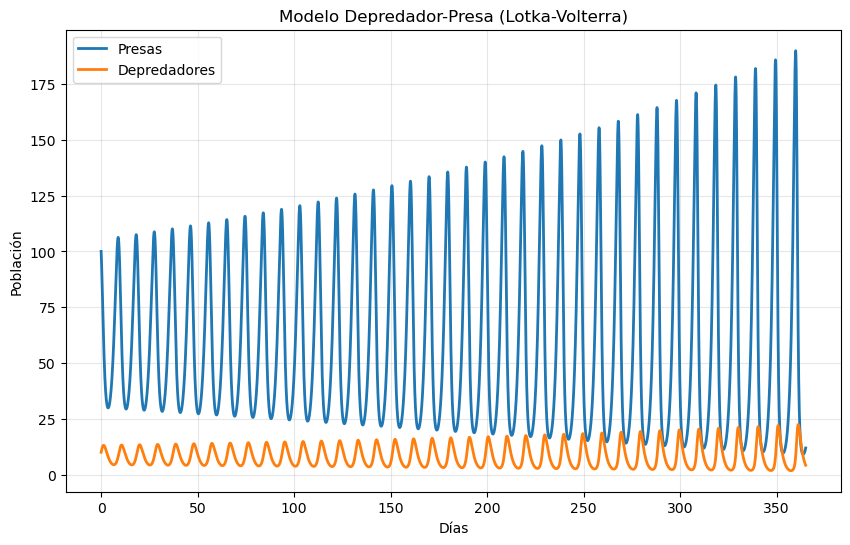

In [80]:
#Simulación
P, D = simu_DP(P0, D0, nu, mu, delta, alpha, dias)

# Designamos el avance temporal ajustado a la cantidad de dias de simulación
dt = 0.01
tiempo = np.arange(0, dias, dt)

#Gráfica de resultados
plt.figure(figsize=(10,6))
plt.plot(tiempo, P, label='Presas', linewidth=2)
plt.plot(tiempo, D, label='Depredadores', linewidth=2)
plt.xlabel('Días')
plt.ylabel('Población')
plt.title('Modelo Depredador-Presa (Lotka-Volterra)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()